<a href="https://colab.research.google.com/github/Qophy/PBML/blob/main/explore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import sys
#import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
CONFIG = {
    # Data
    "data_path": "/content/drive/MyDrive/PINN_WQS_dataset/wq_dataset_node_cycles_1_1DO.csv",

    }

In [7]:
# ─────────────────────────────────────────────
# 3. LOAD DATA
# ─────────────────────────────────────────────
raw_data = pd.read_csv(CONFIG["data_path"])
print("Dataset shape:", raw_data.shape)
print(raw_data.info())


Dataset shape: (18378, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18378 entries, 0 to 18377
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature      18378 non-null  float64
 1   Conductivity     18378 non-null  float64
 2   pH               18378 non-null  float64
 3   DissolvedOxygen  18378 non-null  float64
 4   Time             18378 non-null  object 
 5   hour_sin         18378 non-null  float64
 6   hour_cos         18378 non-null  float64
 7   DOW_sin          18378 non-null  float64
 8   DOW_cos          18378 non-null  float64
 9   Mon_sin          18378 non-null  float64
 10  Mon_cos          18378 non-null  float64
dtypes: float64(10), object(1)
memory usage: 1.5+ MB
None


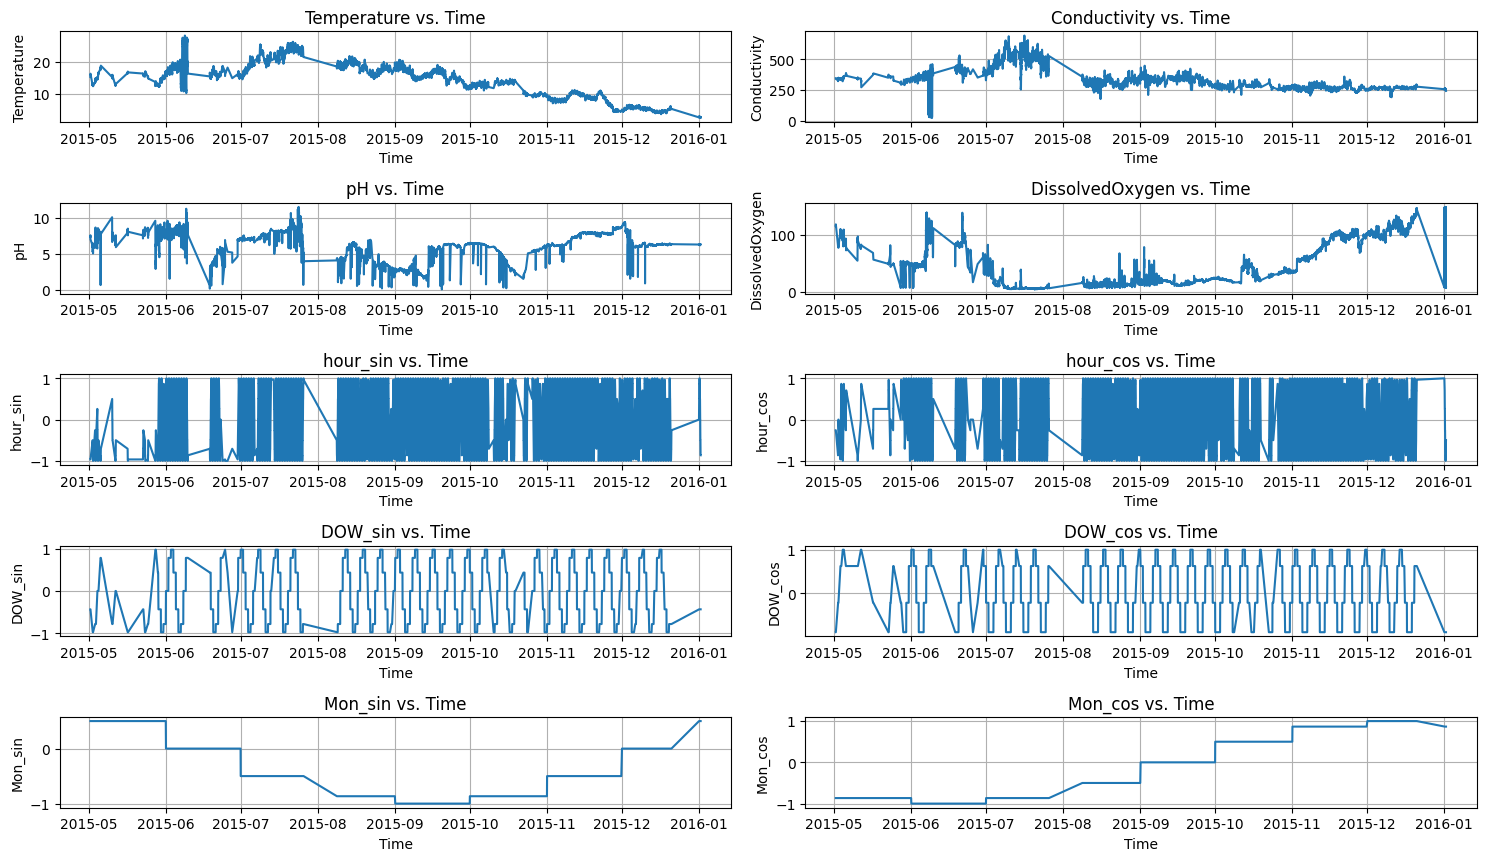

In [8]:
raw_data['Time'] = pd.to_datetime(raw_data['Time'])

features_to_plot = raw_data.columns.drop('Time')

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(len(features_to_plot) // 2 + 1, 2, i + 1)
    plt.plot(raw_data['Time'], raw_data[feature])
    plt.title(f'{feature} vs. Time')
    plt.xlabel('Time')
    plt.ylabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.show()

### Feature Correlation Matrix

Let's compute and visualize the correlation matrix for all numerical features to understand their relationships.

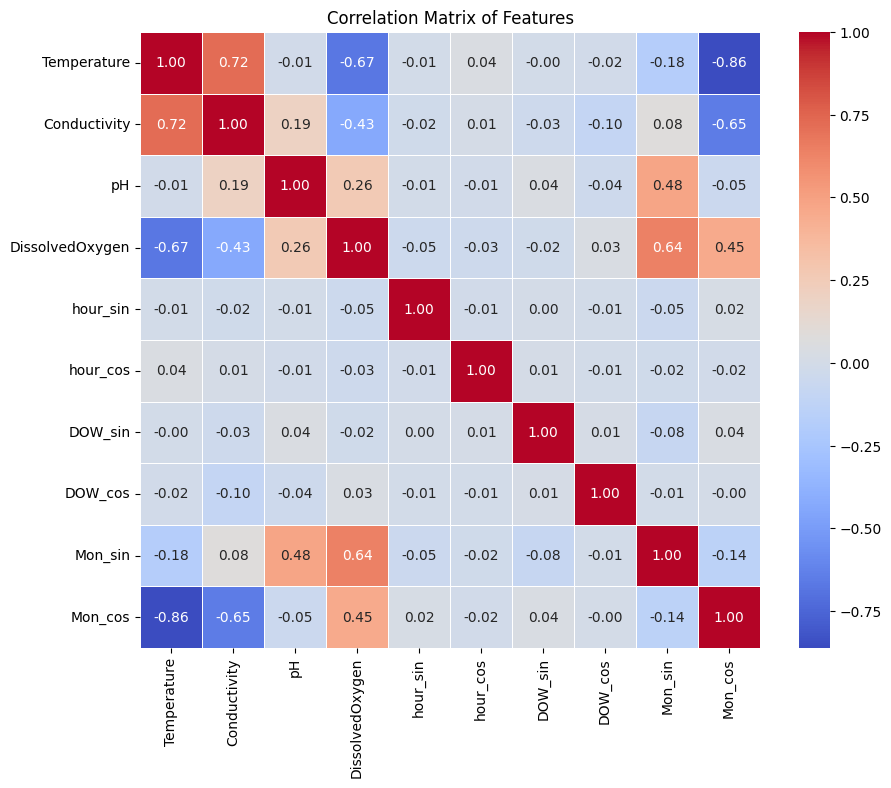

In [12]:
correlation_matrix = raw_data.drop(columns=['Time']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

### Summary Statistics

Let's calculate the summary statistics for the `raw_data` DataFrame to get an overview of its distributions.

In [13]:
display(raw_data.describe())

,Temperature,Conductivity,pH,DissolvedOxygen,Time,hour_sin,hour_cos,DOW_sin,DOW_cos,Mon_sin,Mon_cos
count,18378.000000,18378.000000,18378.000000,18378.000000,18378,18378.000000,1.837800e+04,18378.000000,18378.000000,18378.000000,1.837800e+04
mean,14.792662,337.740200,5.945226,39.614958,2015-09-07 18:39:15.448253440,-0.030390,-2.788282e-03,-0.015273,-0.014856,-0.589544,-6.796033e-02
min,2.380000,22.800000,0.020000,3.700000,2015-05-01 17:20:48,-1.000000,-1.000000e+00,-0.974928,-0.900969,-1.000000,-1.000000e+00
25%,10.190000,274.900000,4.810000,11.400000,2015-07-20 10:46:10.500000,-0.707107,-7.071068e-01,-0.781831,-0.900969,-0.866025,-8.660254e-01
50%,15.590000,317.100000,6.240000,21.300000,2015-09-09 19:30:26.500000,0.000000,-1.836970e-16,0.000000,-0.222521,-0.500000,-1.836970e-16
75%,18.390000,363.675000,7.400000,61.400000,2015-10-28 18:43:51.249999872,0.707107,7.071068e-01,0.781831,0.623490,-0.500000,5.000000e-01
max,28.170000,690.800000,11.500000,149.200000,2016-01-01 16:47:38,1.000000,1.000000e+00,0.974928,1.000000,0.500000,1.000000e+00
std,5.286647,90.533571,1.864752,35.799224,NaN,0.710593,7.029794e-01,0.710181,0.703735,0.384916,7.068901e-01


### Pairplot of Features

Let's create a pairplot to visualize the relationships between all numerical features. This can help identify trends, correlations, and outliers.

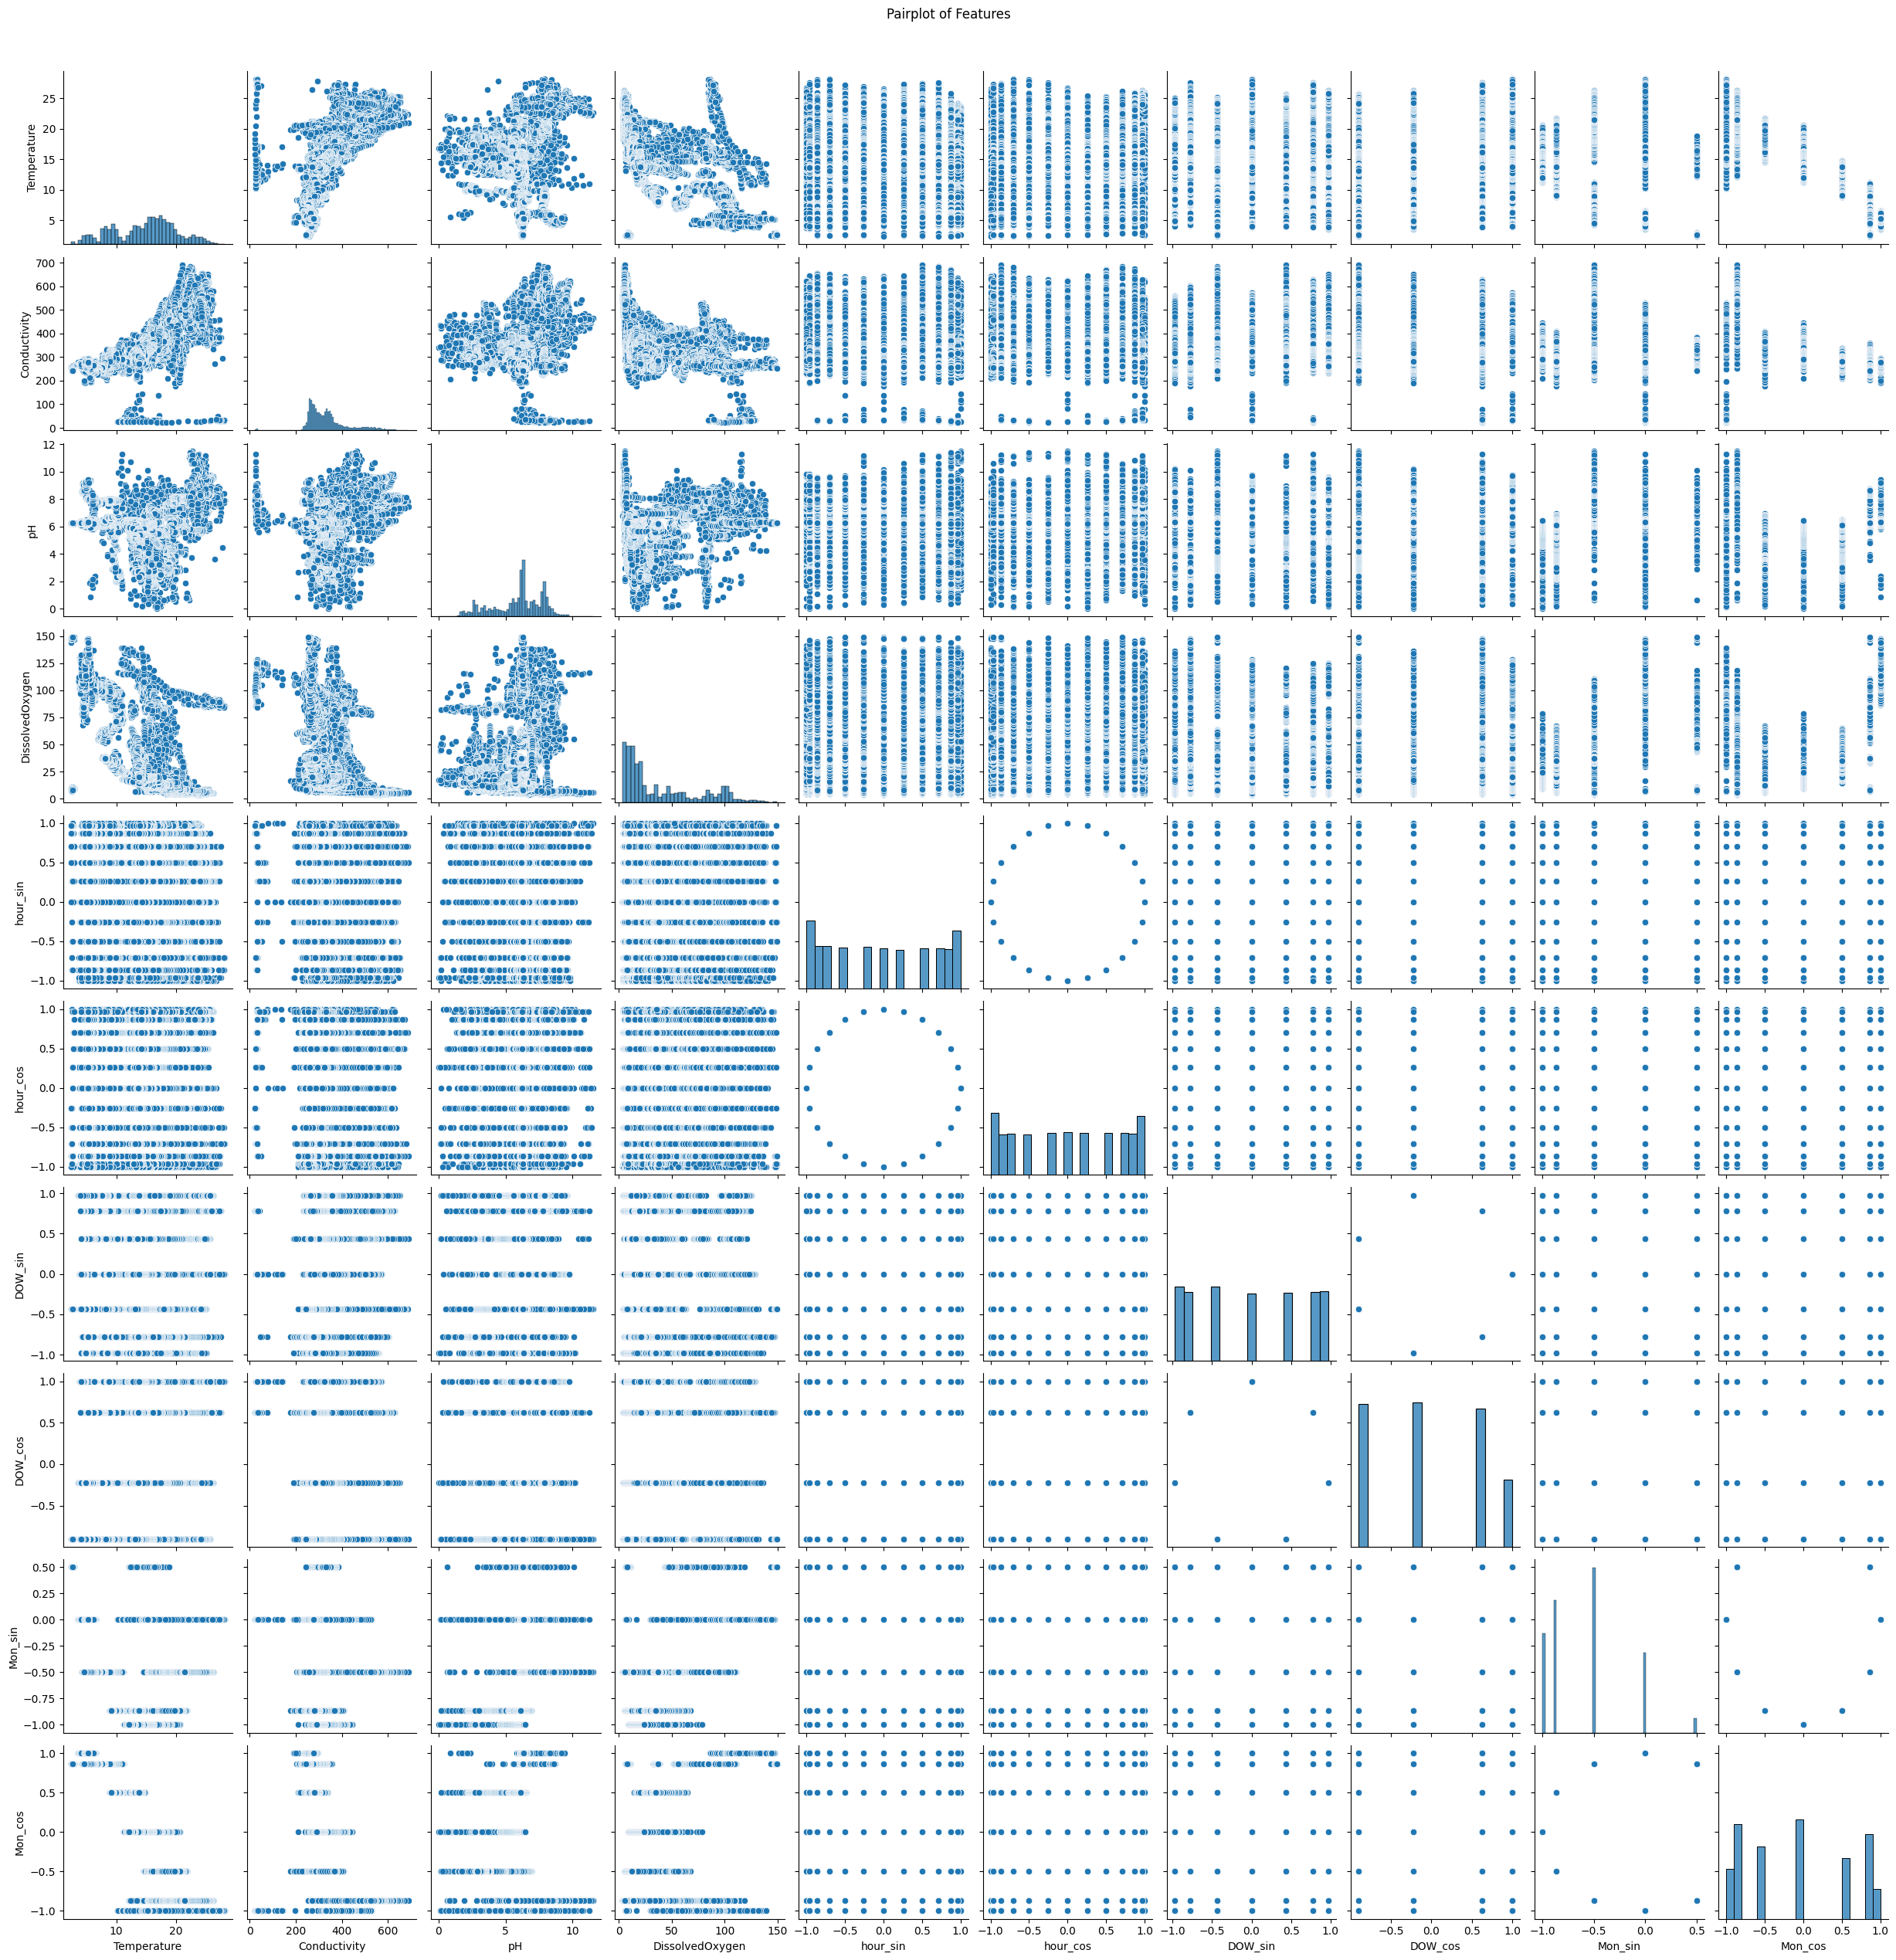

In [14]:
sns.pairplot(raw_data.drop(columns=['Time']))
plt.suptitle('Pairplot of Features', y=1.02) # Adjust suptitle position
plt.show()

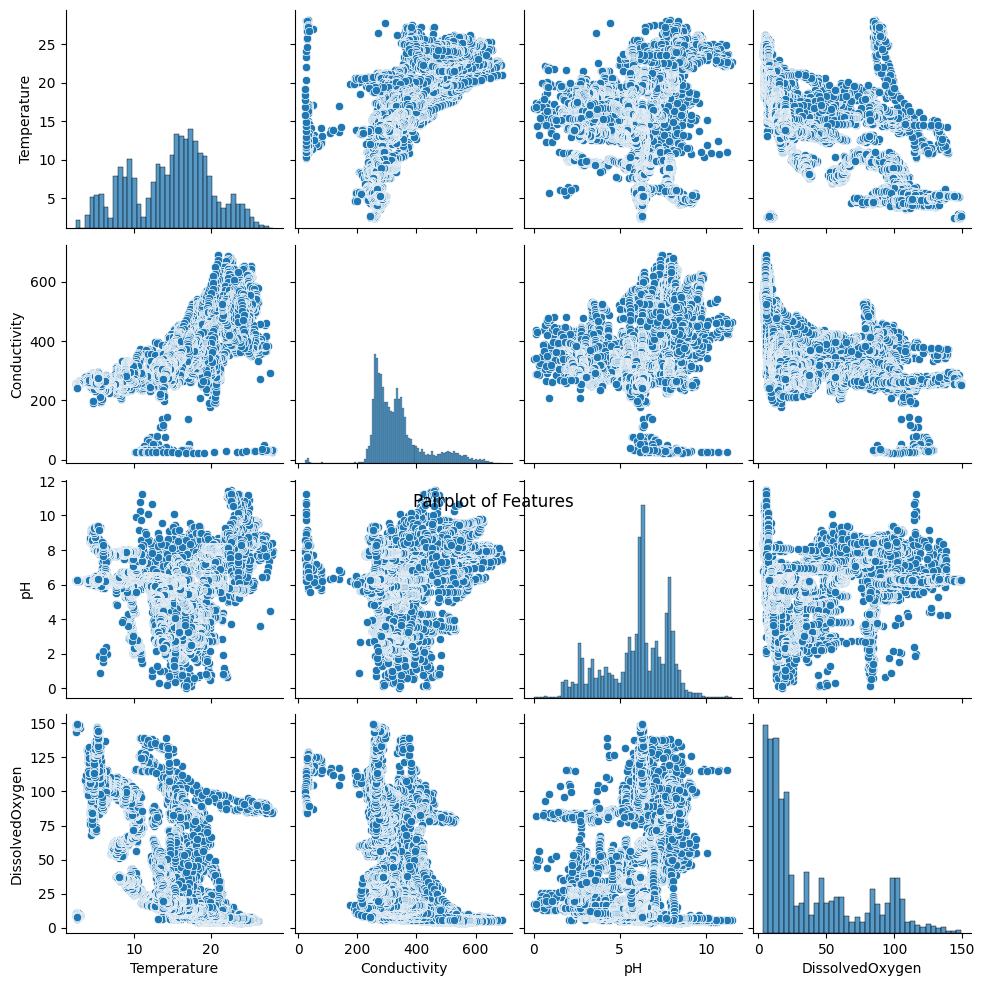

In [17]:
sns.pairplot(raw_data.drop(columns=['Time',	'hour_sin',	'hour_cos',	'DOW_sin',	'DOW_cos',	'Mon_sin',	'Mon_cos']))
plt.suptitle('Pairplot of Features', y=.5) # Adjust suptitle position
plt.show()